## Rekonstrukcija sirovih uzoraka

In [2]:
import numpy as np #ucitavam biblioteke
import matplotlib.pyplot as plt

In [23]:
ks_uzorci = np.genfromtxt('gr.dat', skip_header=2, skip_footer=2) #iz gr.dat ucitavam podatke ali tako da preskacem headere i footere
mJy, G, R = ks_uzorci.T #ucitane podatke sortiram u redove koje pomocu .T transponujem u kolone mJy, G i R

In [24]:
G_uzorak = np.repeat(mJy, G.astype(int)) #G uzorak pravim tako sto vrednost mJy ponavljam onoliko puta koliko je G, odnosno unosim ga toliko puta
#.astype(int) sam stavila jer broj ponavljanja mora da bude ceo broj, a iz podataka sam dobila float
R_uzorak = np.repeat(mJy, R.astype(int)) #isto to radim i za R uzorak
print(G_uzorak) #stampam uzorke
print(R_uzorak)

[-13. -12. -12. -11. -11. -11. -11. -11. -10. -10. -10. -10. -10. -10.
 -10.  -9.  -9.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.
  -7.  -7.  -7.  -7.  -7.  -7.  -7.  -7.  -7.  -7.  -7.  -6.  -6.  -6.
  -6.  -6.  -6.  -6.  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.
  -5.  -5.  -5.  -4.  -4.  -4.  -4.  -4.  -4.  -4.  -4.  -4.  -4.  -4.
  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.
  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -3.  -2.  -2.  -2.
  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.
  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.
  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -2.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.
  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0. 

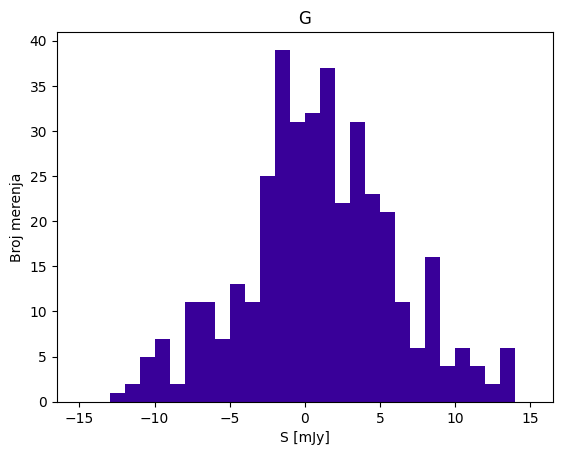

In [25]:
plt.figure()
plt.hist(G_uzorak, bins=np.arange(mJy.min(), mJy.max()+1, 1), color='#390099') #G_uzorak raspodeljujem po binovima od minimalnog do maksimalnog mJy sa korakom 1
plt.xlabel('S [mJy]')
plt.ylabel('Broj merenja')
plt.title('G')
plt.show()

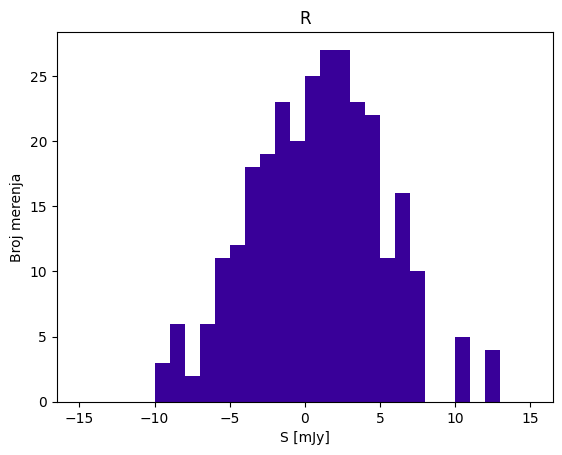

In [26]:
plt.figure() #na isti nacin pravim i histogram za R
plt.hist(R_uzorak, bins=np.arange(mJy.min(), mJy.max()+1, 1), color='#390099')
plt.xlabel('S [mJy]')
plt.ylabel('Broj merenja')
plt.title('R')
plt.show()

Rekonstrukcija sirovih podataka je neophodna jer su podaci u gr.dat dati u obliku broja ponavljanja odredjenih vrednosti gustine fluksa, a za Kolmogorov-Smirnov dvouzoracki test i U-test koriste se pojedinacna merenja.

## Kolmogorov-Smirnov dvouzoracki test

 *Postoji eksces gustine fluksa na ne-slucajnim pozicijama*

Treba da pokazem da G ima vise velikih vrednosti, odnosno da odbacim nultu hipotezu $F_G(x) = F_R(x)$ i proverim smer razlike.

In [27]:
from scipy.stats import ks_2samp #importujem biblioteku

0.06741111309630166
20


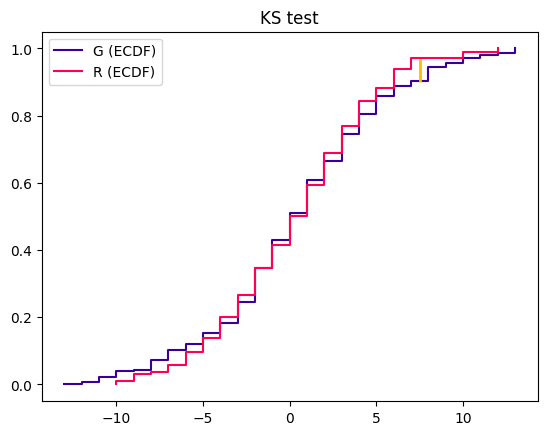

In [30]:
x1 = np.sort(G_uzorak) #sortira sve vrednosti G_uzorak od najmanje ka najvecoj jer nam za ECDF treba da podaci budu sortirani da bi bila monotono rastuca
y1 = np.linspace(0, 1, len(x1)) #pravi niz vrednosti od 0 do 1 ravnomerno rasporedjenih jer nam u ECDF-u svaki podatak raste za 1/n, pa simuliramo kumulativnu verovatnocu

x2 = np.sort(R_uzorak) #isto i za ovaj set podataka
y2 = np.linspace(0, 1, len(x2))

x_all = np.sort(np.unique(np.concatenate([G_uzorak, R_uzorak]))) #spajam G i R u jedan niz i uklanjam duplikate pomocu .unique jer KS poredi dve ECDF funkcije na istim tackama
 
F1 = np.searchsorted(np.sort(G_uzorak), x_all, side='right') / len(G_uzorak) #za svaku vrednost u x_all racuna koliko elemenata G<=x tako sto searchsorted vraća broj elemenata koji bi stali levo od x, a deljenjem len(G) dobijamo verovatnocu po definiciji ECDF-a
F2 = np.searchsorted(np.sort(R_uzorak), x_all, side='right') / len(R_uzorak)

razlika = np.abs(F1 - F2) #racuna apsolutnu razliku ECDF-ova u svakoj tacki kako bismo odredili gde je ona najveca

D = np.max(razlika)

i_max = np.argmax(razlika) #indeks stepenika gde je razlika najveca da bih prikazala na grafiku (zuta vertikalna linija)

print(D)
print(i_max)


plt.figure()

plt.step(x1, y1, label='G (ECDF)', color='#390099') #crta ECDF za G kao stepenastu funkciju
plt.step(x2, y2, label='R (ECDF)', color='#FF0054')

x_mid = (x_all[i_max] + x_all[i_max+1]) / 2 #ovde sam odredjivala sredinu sirine stepenika da bih pozicionirala zutu liniju
y_low = min(F1[i_max], F2[i_max]) #y mi oznacava od koje do koje visine crtam liniju
y_high = max(F1[i_max], F2[i_max])
plt.vlines(x_mid, y_low, y_high, color='#FFBD00', lw=2)

plt.legend()
plt.title("KS test")
plt.show()

In [31]:
#radjeno po instrukcijama
#kod trazi apsolutni maksimum kontinuirane ECDF razlike
res = ks_2samp(G_uzorak, R_uzorak, alternative='less') #Koristi se alternative='less' jer se testira hipoteza o ekscesu fluksa u G uzorku. Ako G ima sistematski vece vrednosti fluksa od R, njegova ECDF funkcija F_G(x) ce rasti sporije od F_R(x), tj. važi F_G(x) < F_R(x).
print(res)

KstestResult(statistic=0.06741111309630159, pvalue=0.20990505201364315, statistic_location=7.0, statistic_sign=-1)


Po KstestResult vidimo da je pvalue=0.20990505201364315 veci od 0.05, te se ne odbacuje nulta hipoteza, no zadatak sam radila i merenjem razlike na izabranim tackama.

For large samples, the null hypothesis is rejected at level $\alpha$ if

$$
D_{n,m} > c(\alpha)\sqrt{\frac{n+m}{n\cdot m}}.
$$

where $n$ and $m$ are the sizes of the first and second sample respectively. - https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test

In [32]:
#koristila sam da je alpha=0.05
c=1.358

D_krit=c*np.sqrt(      ( len(G_uzorak) + len(R_uzorak) )   /   ( len(G_uzorak) * len(R_uzorak) )       ) #racunam kriticnu vrednost Ks statistike D_krit kako bih uporedila sa D iz podataka
print('D kriticno:',D_krit)
print('D :',D)

if(D>D_krit):
    print('Postoji znacajna statisticka razlika i nulta hipoteza se odbacuje')
else:
    print('Ne postoji znacajna statisticka razlika i nulta hipoteza se ne odbacuje')


#provera smera za slucaj da je H0 odbacena:
print('G mean:', np.mean(G_uzorak),', R mean:', np.mean(R_uzorak))
if(np.mean(G_uzorak)>np.mean(R_uzorak)):
    print('Vrednosti za G su u proseku vece od vrednosti za R')
else:
    print('Vrednosti za R su u proseku vece od vrednosti za G')

D kriticno: 0.10553110039178847
D : 0.06741111309630166
Ne postoji znacajna statisticka razlika i nulta hipoteza se ne odbacuje
G mean: 0.4378238341968912 , R mean: 0.32413793103448274
Vrednosti za G su u proseku vece od vrednosti za R


Iako su vrednosti za G u proseku vece od vrednosti za R, statisticka razlika distribucija nije znacajna, te ne mozemo reci da postoji eksces

## U-test

 *Postoji eksces gustine fluksa na ne-slucajnim pozicijama*

https://www.geeksforgeeks.org/machine-learning/mann-whitney-u-test-2/

Null Hypothesis: The two populations are equal, meaning there’s no significant difference between the groups.

In [33]:
from scipy.stats import mannwhitneyu

In [11]:
U, p = mannwhitneyu(G_uzorak, R_uzorak, alternative='greater')
# Kod Mann–Whitney U testa koristi se alternative='greater' jer se direktno porede rangovi vrednosti u dva uzorka. Ako G uzorak ima vece vrednosti fluksa od R uzorka, suma rangova u G ce biti veca, pa se testira hipoteza da je G > R u smislu distribucije.

print("U:", U)
print("p-value:", p)

U: 56613.5
p-value: 0.3988043118334691


In [12]:
alpha_U = 0.05
if p < alpha_U:
    print('Reject Null Hypothesis (Significant difference between two samples)')
else:
    print('Do not Reject Null Hypothesis (No significant difference between two samples)')

Do not Reject Null Hypothesis (No significant difference between two samples)


U-test potvrdjuje rezultat ranije dobijen KS testom.

**Ne postoji eksces gustine fluksa na ne-slucajnim pozicijama.**

## t-test

In [13]:
from scipy.stats import ttest_ind

In [14]:
np.random.seed(0) #postavljam fiksno pocetno stanje generatora slucajnih brojeva

n = 10 #broj posmatranja
eps = 0.2 #uzela sam iz intervala vrednosti (0,0.5)

In [15]:
x = np.random.normal(0, 1, n) #generisem uzorak x od n posmatranja iz normalne raspodele N(0,1)

#mesavina (1-eps)N(0,1) + eps N(0,3):

u = np.random.rand(n) #generisem n uniformnih slucajnih brojeva na intervalu (0,1)

y = np.where(u < eps,np.random.normal(0, 3, n),np.random.normal(0, 1, n)) #za svaku poziciju ako je u<eps uzima vrednost iz N(0,3), a inace iz N(0,1)
#eps je odstupanje od standardne normalne raspodele

In [34]:
stat, p = ttest_ind(x, y) #primenjujem dvouzoracki t-test na uzorke x i y. Testira se nulta hipoteza H0 (jednakost srednjih vrijednosti)

print("x:", x) #ispis generisanog uzorka x iz N(0,1)
print("y:", y) #ispis generisanog uzorka y iz mesovite raspodele
print("t-stat:", stat) #vrednosti t-statistike
print("p-value:", p) #p-vrednost(verovatnoca da se dobije jednaka ili veca razlika sredina ako je H0 tacna)

x: [ 0.39286156 -0.03621819  1.61850889 -0.95889535  0.4470879   0.51675385
  0.2491786   0.25054608 -0.6344453   1.96921485]
y: [-4.84512958 -0.41365938  0.31837775 -1.20862216 -1.76902998  0.05116661
 -0.05467607 -3.60508804 -4.74562705  2.59481104]
t-stat: 2.160436080988715
p-value: 0.044469433031869274


In [35]:
alpha = 0.05 #nivo znacajnosti

if p < alpha:
    print("Odbacuje se H0")
else:
    print("Ne odbacuje se H0")

Odbacuje se H0


In [18]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

np.random.seed(0)

n = 10
alpha = 0.05

eps_values = np.linspace(0, 0.5, 20) #niz vrednosti epsilon kao 20 ravnomerno rasporedjenih vrednosti izmedju 0 i 0.5
rejection_rate = [] #prazna lista

for eps in eps_values: #petlja kroz sve epsilon vrednosti
    count = 0 #brojac za brojanje odbacivanja H0
    
    for _ in range(1000): #1000 ponavljanja eksperimenta
        x = np.random.normal(0, 1, n)
        u = np.random.rand(n)
        y = np.where(u < eps, np.random.normal(0, 3, n), np.random.normal(0, 1, n))
        
        _, p = ttest_ind(x, y) #poredi sredine x i y
        
        if p < alpha:
            count += 1 #ako je p<0.05 odbacuje hipotezu
    
    rejection_rate.append(count / 1000) #racuna procenat odbacivanja

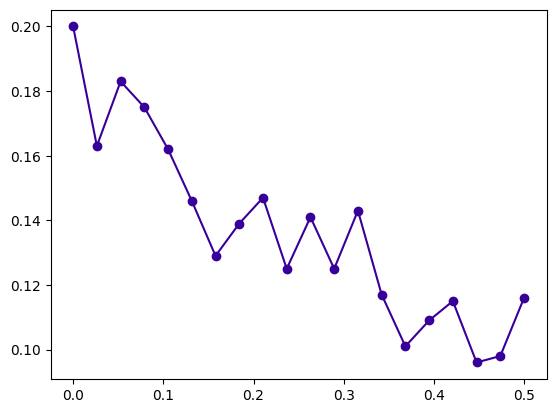

In [36]:
plt.figure()

plt.plot(eps_values, rejection_rate, marker='o', color='#390099') #grafik zavisnosti odbacivanja nulte hipoteze od epsilon

Ponavljam postupak sa $\mu=0.5$

In [37]:
np.random.seed(0)

n = 10
eps = 0.2

x = np.random.normal(0.5, 1, n) #pre je centar raspodele bio 0, u ovom delu zadatka je 0.5, a sve ostalo je isto

#mešavina (1-eps)N(0,1) + eps N(0,3)
u = np.random.rand(n)

y = np.where(
    u < eps,
    np.random.normal(0, 3, n),
    np.random.normal(0, 1, n)
)

stat, p = ttest_ind(x, y)

print("x:", x)
print("y:", y)
print("t-stat:", stat)
print("p-value:", p)

alpha = 0.05

if p < alpha:
    print("Odbacuje se H0")
else:
    print("Ne odbacuje se H0")

x: [ 2.26405235  0.90015721  1.47873798  2.7408932   2.36755799 -0.47727788
  1.45008842  0.34864279  0.39678115  0.9105985 ]
y: [ 0.04575852 -0.18718385  1.53277921  1.46935877 -7.65896945  1.96085579
  2.5933086  -1.98079647 -0.34791215  0.15634897]
t-stat: 1.5083211198548319
p-value: 0.148824272901439
Ne odbacuje se H0


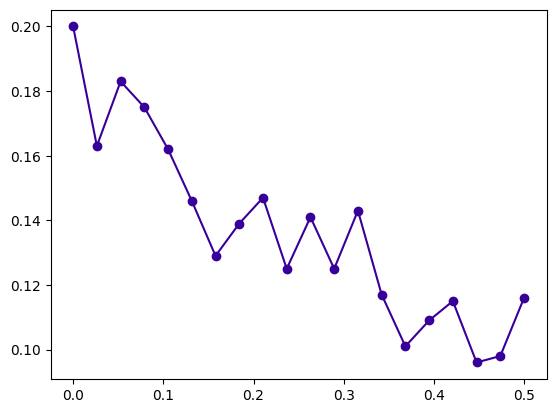

In [38]:
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

np.random.seed(0)

n = 10
alpha = 0.05

eps_values = np.linspace(0, 0.5, 20)
rejection_rate = []

for eps in eps_values:
    count = 0
    
    for _ in range(1000):
        # uzorak 1: N(0,1)
        x = np.random.normal(0.5, 1, n)
        
        # mešavina (1-ε)N(0,1) + εN(0,3)
        u = np.random.rand(n)
        y = np.where(
            u < eps,
            np.random.normal(0, 3, n),
            np.random.normal(0, 1, n)
        )
        
        # t-test
        _, p = ttest_ind(x, y)
        
        if p < alpha:
            count += 1
    
    rejection_rate.append(count / 1000)

plt.figure()

plt.plot(eps_values, rejection_rate, marker='o', color='#390099')